# 🌗 Dynamic Range Alignment

### This notebook (will) implement dynamic range alignment for each pair of digital and film images.
### Goal: To line up the grey-levels/luminance of each pair of images so that the model does not to adjust luminance levels

An explanation of how histogram matching is done for images can be found on [this page by Paul Bourke](https://paulbourke.net/miscellaneous/equalisation/)

Implemented based on code on [this StackOverflow post](https://stackoverflow.com/questions/32655686/histogram-matching-of-two-images-in-python-2-x_)
and [SciKit image tutorials](https://scikit-image.org/docs/stable/auto_examples/color_exposure/plot_histogram_matching.html)


In [23]:
import autorootcwd

In [67]:
import numpy as np
import cv2 as cv
from skimage.exposure import cumulative_distribution

from matplotlib import pyplot as plt

In [25]:
from typing import List, Tuple, Union

### Displays two RGB images side by side

In [61]:
# Display the two images
def display_two_images(im1, im2):
    fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
    axs[0].imshow(im1)
    axs[1].imshow(im2)

### Functions to compute CDF and match the luminance histograms of two images
##### Matches the luminance of the template image to the source image
##### This code can be repurposed to match the histograms of any channel, not just luminance

In [74]:
def cdf(channel):
    '''
    computes the CDF of an image im as 2D numpy ndarray
    '''
    cdf, b = cumulative_distribution(channel) 
    # pad the beginning and ending pixels and their CDF values
    cdf = np.insert(cdf, 0, [0]*b[0])
    cdf = np.append(cdf, [1]*(255-b[-1]))
    return cdf

def hist_matching(c, c_t, channel):
    '''
    c: CDF of input image computed with the function cdf()
    c_t: CDF of template image computed with the function cdf()
    im: input image as 2D numpy ndarray
    returns the modified pixel values
    ''' 
    pixels = np.arange(256)
    # find closest pixel-matches corresponding to the CDF of the input image, given the value of the CDF H of   
    # the template image at the corresponding pixels, s.t. c_t = H(pixels) <=> pixels = H-1(c_t)
    new_pixels = np.interp(c, c_t, pixels) 
    new_channel = (np.reshape(new_pixels[channel.ravel()], channel.shape)).astype(np.uint8)
    return new_channel


def match_luminance(template_path, source_path):
    """
    Matches the luminance of the source image to the template image
    """

    lab1 = cv.cvtColor(cv.imread(template_path), cv.COLOR_BGR2LAB)
    lab2 = cv.cvtColor(cv.imread(source_path), cv.COLOR_BGR2LAB)

    # Split into channels
    l1, a1, b1 = cv.split(lab1)
    l2, a2, b2 = cv.split(lab2)

    cdf1 = cdf(l1)
    cdf2 = cdf(l2)
    new_l2 = hist_matching(cdf2, cdf1, l2) # match the histograms of l2 to l1

    lab2 = cv.merge((new_l2, a2, b2)) # merge the new L channel with the original A and B channels

    # convert back to RBG and then return result
    im1 = cv.cvtColor(lab1, cv.COLOR_LAB2RGB)
    im2 = cv.cvtColor(lab2, cv.COLOR_LAB2RGB)

    return im1, im2


### Adjusts the luminance of the source image to have the same average luminance of the template image

In [58]:
def align_luminance_mean(template_path, source_path):
    """
    Align the mean luminance of two images
    First argument is the image to be aligned to
    Second argument is the image to be adjusted to match the first
    """
    # Convert to LAB
    lab1 = cv.cvtColor(cv.imread(template_path), cv.COLOR_BGR2LAB)
    lab2 = cv.cvtColor(cv.imread(source_path), cv.COLOR_BGR2LAB)

    # Split into channels
    l1, a1, b1 = cv.split(lab1)
    l2, a2, b2 = cv.split(lab2)

    # Align luminance histogram of the two images
    l1_hist, _ = np.histogram(l1.flatten(), 256, [0, 256])

    # Align the mean luminance of the two images
    l2 = cv.add(l2, np.mean(l1) - np.mean(l2))

    # Merge the channels back together
    lab2 = cv.merge((l2, a2, b2))

    # Convert back to RGB

    im1 = cv.cvtColor(lab1, cv.COLOR_LAB2RGB)
    im2 = cv.cvtColor(lab2, cv.COLOR_LAB2RGB)

    return im1, im2


### Don't need this equalize function probably, will add comments later

In [76]:
def equalize_histogram(img_path):

    img = cv.imread(img_path, cv.IMREAD_GRAYSCALE)
    assert img is not None, "file could not be read, check with os.path.exists()"
    
    hist,bins = np.histogram(img.flatten(),256,[0,256])
    
    cdf = hist.cumsum()
    cdf_normalized = cdf * float(hist.max()) / cdf.max()
    
    plt.plot(cdf_normalized, color = 'b')
    plt.hist(img.flatten(),256,[0,256], color = 'r')
    plt.xlim([0,256])
    plt.legend(('cdf','histogram'), loc = 'upper left')
    plt.show()

    # find the minimum histogram value (excluding 0) and apply the histogram equalization equation
    cdf_m = np.ma.masked_equal(cdf,0)
    cdf_m = (cdf_m - cdf_m.min())*255/(cdf_m.max()-cdf_m.min())
    cdf = np.ma.filled(cdf_m,0).astype('uint8')

    img_normalized = cdf[img]

    # its histogram and cdf as before 
    hist,bins = np.histogram(img_normalized.flatten(),256,[0,256])
    cdf = hist.cumsum()
    cdf_normalized = cdf * hist.max() / cdf.max()
    plt.plot(cdf_normalized, color = 'b')
    plt.hist(img_normalized.flatten(),256,[0,256], color = 'r')
    plt.xlim([0,256])
    plt.legend(('cdf','histogram'), loc = 'upper left')
    plt.show()

    fig, axs = plt.subplots(ncols=2, figsize=(10, 5))
    axs[0].imshow(img)
    axs[1].imshow(img_normalized)

    return img_normalized

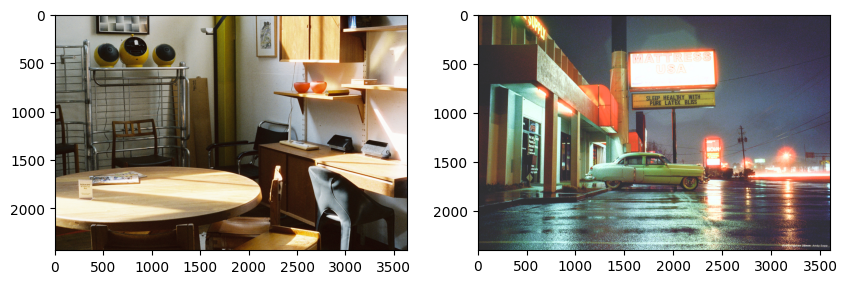

In [75]:
# Load image example
template = 'imgs/table_cafe_film.JPG'
source = 'imgs/cinestill-800t.jpg'

# call function on example images
aligned_target, aligned_source = align_luminance_mean(template, source)

display_two_images(aligned_target, aligned_source)

In [78]:
#equalize_histogram('imgs/table_cafe_film.JPG')

In [59]:
# def align_luminance_quantiles(template_path, source_path):
#     """
#     Align the luminance of two images
#     """
#     # Convert to LAB
#     lab1 = cv.cvtColor(cv.imread(template_path), cv.COLOR_BGR2LAB)
#     lab2 = cv.cvtColor(cv.imread(source_path), cv.COLOR_BGR2LAB)

#     # Split into channels
#     l1, a1, b1 = cv.split(lab1)
#     l2, a2, b2 = cv.split(lab2)

#     oldshape = l2.shape
#     source = l2.ravel()
#     template = l1.ravel()

#     np.histogram(l1.flatten(), 256, [0, 256])

#     # get the set of unique pixel values and their corresponding indices and
#     # counts
#     s_values, bin_idx, s_counts = np.unique(source, return_inverse=True,
#                                             return_counts=True)
#     t_values, t_counts = np.unique(template, return_counts=True)

#     # take the cumsum of the counts and normalize by the number of pixels to
#     # get the empirical cumulative distribution functions for the source and
#     # template images (maps pixel value --> quantile)
#     s_quantiles = np.cumsum(s_counts).astype(np.float64)
#     s_quantiles /= s_quantiles[-1]
#     t_quantiles = np.cumsum(t_counts).astype(np.float64)
#     t_quantiles /= t_quantiles[-1]

#     # interpolate linearly to find the pixel values in the template image
#     # that correspond most closely to the quantiles in the source image
#     interp_t_values = np.interp(s_quantiles, t_quantiles, t_values)

#     new_l1 = interp_t_values[bin_idx].reshape(oldshape)

#     lab2 = cv.merge((new_l1, a1, b1))

#     return lab1, lab2